# Entraînement et évaluation des modèles de classification

## Objectif de ce notebook
Entrainement et évaluation des **trois modèles** de classification binaire (TruePositive vs Non-TruePositive) sur des incidents de cybersécurité issus du dataset GUIDE de Microsoft.

### Modèles entraînés
1. **Régression logistique** (avec PCA)
2. **K-Nearest Neighbors (KNN)** (avec PCA)
3. **Random Forest** (sans PCA — justification ci-dessous)

### Choix des métriques
Dans un contexte de cybersécurité, nous privilégions le **F1-Score Macro** comme métrique principale :
- **Pourquoi pas l'accuracy ?** Les classes sont déséquilibrées. L'accuracy peut être artificiellement élevée en prédisant toujours la classe majoritaire.
- **Pourquoi F1 Macro ?** Il calcule le F1 pour chaque classe puis en fait la moyenne non pondérée, ce qui force le modèle à bien performer sur **les deux classes**. Un modèle qui ignore les TruePositive sera pénalisé.
- **Pourquoi pas le F1 Weighted ?** Il donnerait plus de poids à la classe majoritaire, ce qui masquerait une mauvaise détection des vrais incidents.
- **Precision et Recall** sont aussi surveillés car en sécurité, manquer un vrai incident (faible rappel) est plus grave qu'un faux positif.

In [3]:
# -- Bibliotheques --
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, RandomizedSearchCV, cross_val_predict
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score,
    precision_score, recall_score
)

# -- Constantes --
CIBLE_MAP = {'Non-TruePositive': 0, 'TruePositive': 1}
CIBLE_MAP_INV = {v: k for k, v in CIBLE_MAP.items()}
TARGET_NAMES = ['Non-TP (0)', 'TP (1)']
print("Bibliotheques importees avec succes.")

Bibliotheques importees avec succes.


## 1. Chargement des données et Analyse en Composantes Principales (PCA)

Les données transformées (StandardScaler + OneHotEncoder) sont chargées depuis `donnees_transformees.npz`, exporté par le notebook de prétraitement.

### Pourquoi la PCA ?
Après encodage OneHot, nous obtenons **~185 features**. Ce nombre élevé pose deux problèmes :
- **Malédiction de la dimensionnalité** : le KNN et la régression logistique sont très sensibles au bruit dans les dimensions non informatives.
- **Temps de calcul** : plus de features = plus lent à entraîner et à optimiser.

La PCA réduit la dimensionnalité en conservant **95% de la variance expliquée**, ce qui élimine le bruit tout en gardant l'essentiel de l'information.

Train : (75710, 231)
Test  : (18928, 231)
Features : 231


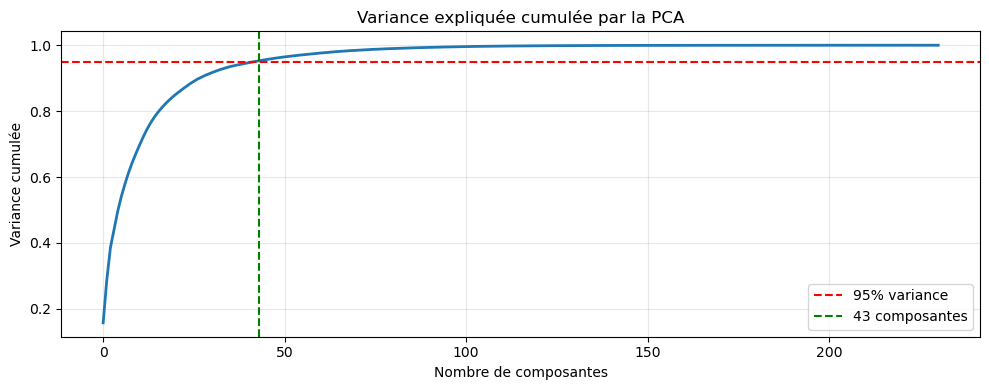


Composantes pour 95% de variance : 43 (sur 231)
Dimensions après PCA : 43 composantes
Dimensions après PCA : 43 composantes


In [4]:
# Chargement des données transformées
data = np.load('donnees_transformees.npz', allow_pickle=True)
X_train_transformed = data['X_train']
X_test_transformed = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names_all = data['feature_names'].tolist()

print(f"Train : {X_train_transformed.shape}")
print(f"Test  : {X_test_transformed.shape}")
print(f"Features : {len(feature_names_all)}")

# Analyse de la variance
pca_full = PCA(random_state=2026)
pca_full.fit(X_train_transformed)
variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_)
n_composantes_95 = np.argmax(variance_cumulee >= 0.95) + 1

# Visualisation
plt.figure(figsize=(10, 4))
plt.plot(variance_cumulee, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axvline(x=n_composantes_95, color='g', linestyle='--', label=f'{n_composantes_95} composantes')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée')
plt.title('Variance expliquée cumulée par la PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nComposantes pour 95% de variance : {n_composantes_95} (sur {X_train_transformed.shape[1]})")

# Application PCA
pca = PCA(n_components=0.95, random_state=2026)
X_train_pca = pca.fit_transform(X_train_transformed)
X_test_pca  = pca.transform(X_test_transformed)
print(f"Dimensions après PCA : {X_train_pca.shape[1]} composantes")

## 2. Régression logistique

### Démarche
1. **Baseline sans PCA** pour mesurer la performance de référence
2. **Baseline avec PCA** pour voir l'impact de la réduction de dimension
3. **Optimisation avec RandomizedSearchCV** sur les données PCA

### Pourquoi RandomizedSearchCV plutôt que GridSearchCV ?
Avec 20 valeurs de `C`, 2 pénalités et 2 pondérations de classe, un GridSearch exhaustif serait trop long. Le RandomizedSearch teste un sous-ensemble aléatoire des combinaisons, ce qui est plus efficace pour un espace de recherche continu comme `C`.

### Hyperparamètres explorés
- `C` : force de régularisation (logspace de 0.001 à 1000)
- `penalty` : L1 (sélection de features) vs L2 (shrinkage)
- `class_weight` : None vs balanced (compensation du déséquilibre)
- `solver` : saga (supporte L1 et L2)

In [5]:
# --- Sans PCA ---
logistic_baseline_nopca = LogisticRegression(max_iter=1000, random_state=42)
logistic_baseline_nopca.fit(X_train_transformed, y_train)
y_pred_bl_nopca = logistic_baseline_nopca.predict(X_test_transformed)
acc_bl_nopca = accuracy_score(y_test, y_pred_bl_nopca)
f1_bl_nopca  = f1_score(y_test, y_pred_bl_nopca, average='macro')

# --- Avec PCA ---
logistic_baseline = LogisticRegression(max_iter=1000, random_state=42)
logistic_baseline.fit(X_train_pca, y_train)
y_pred_baseline = logistic_baseline.predict(X_test_pca)
acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline  = f1_score(y_test, y_pred_baseline, average='macro')

print(f"Sans PCA — Accuracy: {acc_bl_nopca:.4f}, F1 Macro: {f1_bl_nopca:.4f}")
print(f"Avec PCA — Accuracy: {acc_baseline:.4f}, F1 Macro: {f1_baseline:.4f}")

Sans PCA — Accuracy: 0.8024, F1 Macro: 0.7637
Avec PCA — Accuracy: 0.7913, F1 Macro: 0.7516


In [6]:
# -- Optimisation via RandomizedSearchCV --
param_distributions = {
    'C': np.logspace(-3, 3, 20),
    'penalty': ['l1', 'l2'],
    'solver': ['saga'],
    'class_weight': [None, 'balanced']
}

grid_search_lr = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=param_distributions,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=2026),
    n_jobs=-1, verbose=1, return_train_score=True
)
grid_search_lr.fit(X_train_pca, y_train)

# Meilleur modèle
best_regression = grid_search_lr.best_estimator_
y_pred_reg = best_regression.predict(X_test_pca)

reg_acc  = accuracy_score(y_test, y_pred_reg)
reg_f1   = f1_score(y_test, y_pred_reg, average='macro')
reg_prec = precision_score(y_test, y_pred_reg, average='macro')
reg_rec  = recall_score(y_test, y_pred_reg, average='macro')

print(f"\nMeilleurs hyperparamètres : {grid_search_lr.best_params_}")
print(f"\nAccuracy : {reg_acc:.4f} | Precision : {reg_prec:.4f} | Recall : {reg_rec:.4f} | F1 Macro : {reg_f1:.4f}")
print(f"\n{classification_report(y_test, y_pred_reg, target_names=['Non-TruePositive', 'TruePositive'])}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Meilleurs hyperparamètres : {'solver': 'saga', 'penalty': 'l1', 'class_weight': None, 'C': np.float64(0.3359818286283781)}

Accuracy : 0.7914 | Precision : 0.7896 | Recall : 0.7376 | F1 Macro : 0.7516

                  precision    recall  f1-score   support

Non-TruePositive       0.79      0.92      0.85     12284
    TruePositive       0.79      0.56      0.65      6644

        accuracy                           0.79     18928
       macro avg       0.79      0.74      0.75     18928
    weighted avg       0.79      0.79      0.78     18928


Meilleurs hyperparamètres : {'solver': 'saga', 'penalty': 'l1', 'class_weight': None, 'C': np.float64(0.3359818286283781)}

Accuracy : 0.7914 | Precision : 0.7896 | Recall : 0.7376 | F1 Macro : 0.7516

                  precision    recall  f1-score   support

Non-TruePositive       0.79      0.92      0.85     12284
    TruePositive       0.79      0.56      0.65      6644

      

       Metrique  Sans PCA  PCA + Baseline  PCA + Optimise    Gain
       Accuracy  0.802356        0.791314        0.791367 -0.0110
Macro Precision  0.806100        0.789493        0.789584 -0.0165
   Macro Recall  0.748321        0.737603        0.737644 -0.0107
 Macro F1-Score  0.763732        0.751555        0.751605 -0.0121


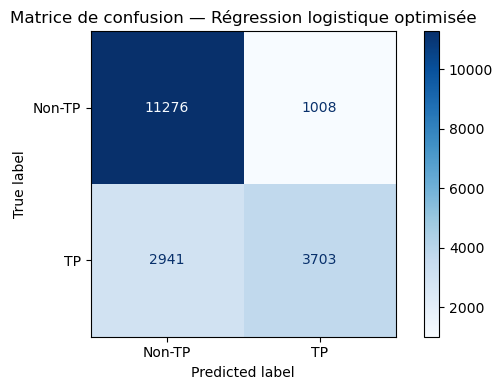

In [7]:
# -- Comparaison Régression logistique --
comparison_lr = pd.DataFrame({
    'Metrique': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score'],
    'Sans PCA': [acc_bl_nopca, precision_score(y_test, y_pred_bl_nopca, average='macro'),
                 recall_score(y_test, y_pred_bl_nopca, average='macro'), f1_bl_nopca],
    'PCA + Baseline': [acc_baseline, precision_score(y_test, y_pred_baseline, average='macro'),
                       recall_score(y_test, y_pred_baseline, average='macro'), f1_baseline],
    'PCA + Optimise': [reg_acc, reg_prec, reg_rec, reg_f1]
})
comparison_lr['Gain'] = (comparison_lr['PCA + Optimise'] - comparison_lr['Sans PCA']).round(4)
print(comparison_lr.to_string(index=False))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_reg, display_labels=['Non-TP', 'TP'], ax=ax, cmap='Blues')
ax.set_title('Matrice de confusion — Régression logistique optimisée')
plt.tight_layout()
plt.show()

## 3. K-Nearest Neighbors (KNN)

### Démarche
1. **Baseline sans PCA** (K=5) vs **avec PCA** (K=5)
2. **Elbow Method** pour trouver le K optimal
3. **GridSearchCV** pour affiner K, la pondération et la métrique de distance

### Pourquoi la PCA est essentielle pour le KNN ?
Le KNN calcule des distances entre observations. Dans un espace à 185 dimensions :
- Toutes les distances tendent à se ressembler (phénomène de concentration des distances)
- Le bruit dans les dimensions non informatives dégrade les voisinages

La PCA corrige ces deux problèmes en projetant les données dans un espace plus compact et informatif.

### Hyperparamètres explorés
- `n_neighbors` : nombre de voisins (centré autour du K trouvé par Elbow)
- `weights` : uniform (vote égal) vs distance (voisins proches comptent plus)
- `p` : 1 (Manhattan) vs 2 (Euclidienne)

Sans PCA (K=5) — Accuracy: 0.7801, F1 Macro: 0.7473
Avec PCA (K=5) — Accuracy: 0.7787, F1 Macro: 0.7461


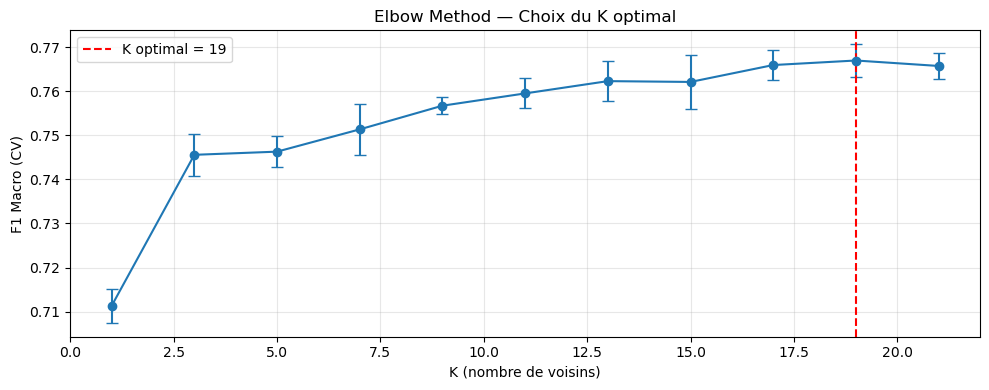


K optimal (Elbow) : 19


In [8]:
# --- KNN Baseline : Sans PCA vs Avec PCA ---
knn_baseline_nopca = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn_baseline_nopca.fit(X_train_transformed, y_train)
y_pred_knn_nopca = knn_baseline_nopca.predict(X_test_transformed)
acc_knn_nopca = accuracy_score(y_test, y_pred_knn_nopca)
f1_knn_nopca  = f1_score(y_test, y_pred_knn_nopca, average='macro')

knn_baseline = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn_baseline.fit(X_train_pca, y_train)
y_pred_knn_baseline = knn_baseline.predict(X_test_pca)
acc_knn_baseline = accuracy_score(y_test, y_pred_knn_baseline)
f1_knn_baseline  = f1_score(y_test, y_pred_knn_baseline, average='macro')

print(f"Sans PCA (K=5) — Accuracy: {acc_knn_nopca:.4f}, F1 Macro: {f1_knn_nopca:.4f}")
print(f"Avec PCA (K=5) — Accuracy: {acc_knn_baseline:.4f}, F1 Macro: {f1_knn_baseline:.4f}")

# --- Elbow Method ---
k_range = list(range(1, 22, 2))
cv_scores_mean, cv_scores_std = [], []
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=2026)

for k in k_range:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k, n_jobs=-1),
                             X_train_pca, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

best_k = k_range[np.argmax(cv_scores_mean)]

plt.figure(figsize=(10, 4))
plt.errorbar(k_range, cv_scores_mean, yerr=cv_scores_std, marker='o', capsize=4)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'K optimal = {best_k}')
plt.xlabel('K (nombre de voisins)')
plt.ylabel('F1 Macro (CV)')
plt.title('Elbow Method — Choix du K optimal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\nK optimal (Elbow) : {best_k}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Ecart Train-Test : 0.0130 → OK
Ecart Train-Test : 0.0130 → OK

Meilleurs hyperparamètres : {'metric': 'minkowski', 'n_neighbors': 19, 'p': 2, 'weights': 'distance'}
Accuracy : 0.8012 | Precision : 0.7895 | Recall : 0.7623 | F1 Macro : 0.7721

                  precision    recall  f1-score   support

Non-TruePositive       0.82      0.89      0.85     12284
    TruePositive       0.76      0.63      0.69      6644

        accuracy                           0.80     18928
       macro avg       0.79      0.76      0.77     18928
    weighted avg       0.80      0.80      0.80     18928


Meilleurs hyperparamètres : {'metric': 'minkowski', 'n_neighbors': 19, 'p': 2, 'weights': 'distance'}
Accuracy : 0.8012 | Precision : 0.7895 | Recall : 0.7623 | F1 Macro : 0.7721

                  precision    recall  f1-score   support

Non-TruePositive       0.82      0.89      0.85     12284
    TruePositive       0.76      0.63      0.69

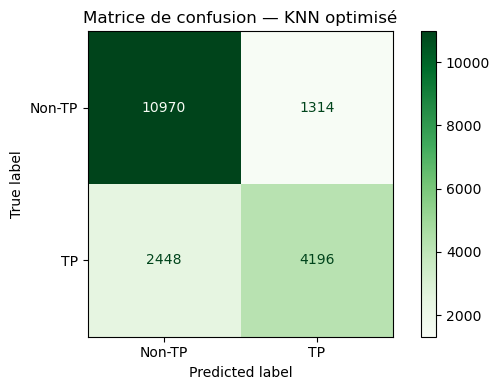

In [9]:
# -- GridSearchCV : optimisation fine du KNN --
k_fine_range = list(range(max(1, best_k - 4), best_k + 6, 2))

param_grid_knn = {
    'n_neighbors': k_fine_range,
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski'],
    'p': [1, 2]
}

grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid=param_grid_knn,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=2026),
    n_jobs=-1, verbose=1, return_train_score=True
)
grid_search_knn.fit(X_train_pca, y_train)

# Vérification surapprentissage
results_knn = pd.DataFrame(grid_search_knn.cv_results_)
best_train_knn = results_knn.loc[results_knn['rank_test_score'] == 1, 'mean_train_score'].values[0]
gap_knn = best_train_knn - grid_search_knn.best_score_
print(f"Ecart Train-Test : {gap_knn:.4f} → {'Surapprentissage' if gap_knn > 0.05 else 'OK'}")

# Évaluation finale
best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_pca)

knn_acc  = accuracy_score(y_test, y_pred_knn)
knn_f1   = f1_score(y_test, y_pred_knn, average='macro')
knn_prec = precision_score(y_test, y_pred_knn, average='macro')
knn_rec  = recall_score(y_test, y_pred_knn, average='macro')

print(f"\nMeilleurs hyperparamètres : {grid_search_knn.best_params_}")
print(f"Accuracy : {knn_acc:.4f} | Precision : {knn_prec:.4f} | Recall : {knn_rec:.4f} | F1 Macro : {knn_f1:.4f}")
print(f"\n{classification_report(y_test, y_pred_knn, target_names=['Non-TruePositive', 'TruePositive'])}")

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, display_labels=['Non-TP', 'TP'], ax=ax, cmap='Greens')
ax.set_title('Matrice de confusion — KNN optimisé')
plt.tight_layout()
plt.show()

In [11]:
# -- Tableau comparatif KNN --
knn_comparison = pd.DataFrame({
    'Modèle': ['KNN Baseline (sans PCA)', 'KNN Baseline (avec PCA)', 'KNN Optimisé (avec PCA)'],
    'Accuracy': [acc_knn_nopca, acc_knn_baseline, knn_acc],
    'Precision Macro': [
        precision_score(y_test, y_pred_knn_nopca, average='macro'),
        precision_score(y_test, y_pred_knn_baseline, average='macro'),
        knn_prec
    ],
    'Recall Macro': [
        recall_score(y_test, y_pred_knn_nopca, average='macro'),
        recall_score(y_test, y_pred_knn_baseline, average='macro'),
        knn_rec
    ],
    'F1 Macro': [f1_knn_nopca, f1_knn_baseline, knn_f1]
})
print(knn_comparison.to_string(index=False))

                 Modèle  Accuracy  Precision Macro  Recall Macro  F1 Macro
KNN Baseline (sans PCA)  0.780061         0.764221      0.738400  0.747347
KNN Baseline (avec PCA)  0.778688         0.762275      0.737411  0.746101
KNN Optimisé (avec PCA)  0.801247         0.789542      0.762289  0.772051


## 4. Random Forest

### Pourquoi le Random Forest n'utilise PAS la PCA

Contrairement à la Régression Logistique et au KNN, le Random Forest **n'utilise pas la PCA**. Ce choix est délibéré et repose sur plusieurs raisons :

1. **Robustesse native à la haute dimensionnalité** : Les arbres de décision sélectionnent automatiquement les features les plus discriminantes à chaque split. Ils ne souffrent pas de la malédiction de la dimensionnalité comme les modèles basés sur les distances.

2. **Importance des features** : Le Random Forest fournit un classement naturel de l'importance de chaque variable (`feature_importances_`). La PCA transforme les features originales en composantes abstraites, ce qui **détruit cette interprétabilité**.

3. **Sélection de features par importance cumulative** : Au lieu de la PCA, nous appliquons une **sélection de features** basée sur l'importance cumulée (seuils de 80% à 95%). Cette approche est plus adaptée car elle conserve la signification métier des variables.

4. **Performances empiriques** : Les tests montrent que le RF sans PCA performe aussi bien, voire mieux, qu'avec PCA.

### Stratégie d'optimisation

- **RandomizedSearchCV** (n_iter=50) : Exploration efficace d'un espace d'hyperparamètres large (n_estimators, max_depth, min_samples_split/leaf, max_features, bootstrap)
- **Sélection de features** : On entraîne un RF initial, on classe les features par importance, puis on teste différents seuils d'importance cumulée pour trouver le sous-ensemble optimal
- **Optimisation du seuil de décision** : Le seuil par défaut de 0.5 n'est pas toujours optimal pour maximiser le F1 Macro. On explore des seuils de 0.20 à 0.80 via cross-validation

RF Baseline — Accuracy: 0.7751 | F1 Macro: 0.7618

              precision    recall  f1-score   support

  Non-TP (0)       0.86      0.78      0.82     12284
      TP (1)       0.65      0.77      0.71      6644

    accuracy                           0.78     18928
   macro avg       0.76      0.77      0.76     18928
weighted avg       0.79      0.78      0.78     18928



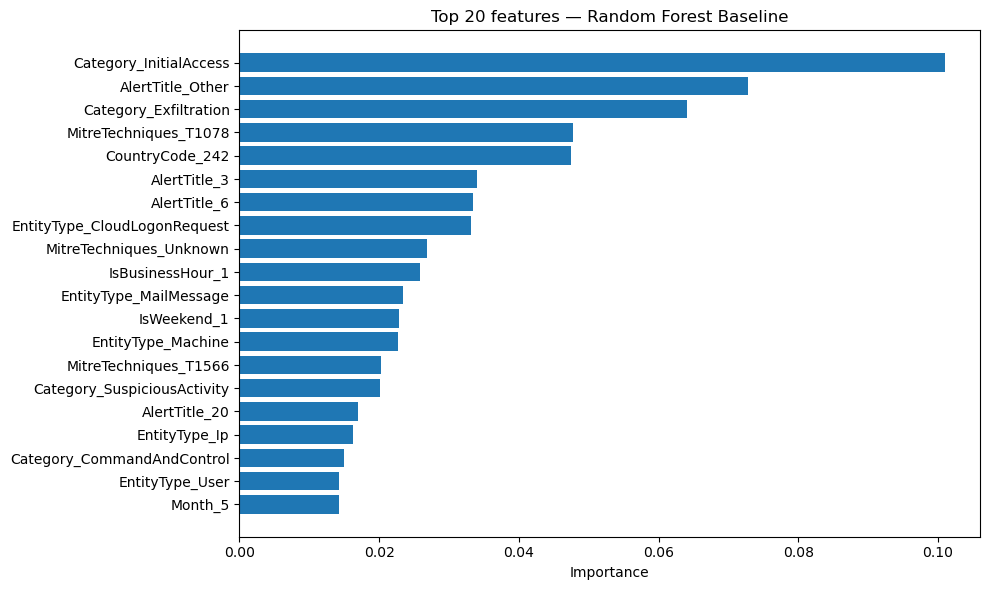

In [12]:
# --- Random Forest Baseline ---
# On recharge les données transformées (sans PCA)
data = np.load('donnees_transformees.npz', allow_pickle=True)
X_train_transformed = data['X_train']
X_test_transformed = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names_all = data['feature_names'].tolist()

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=2026,
    n_jobs=-1
)
rf_baseline.fit(X_train_transformed, y_train)
y_pred_rf_base = rf_baseline.predict(X_test_transformed)

rf_base_acc  = accuracy_score(y_test, y_pred_rf_base)
rf_base_f1   = f1_score(y_test, y_pred_rf_base, average='macro')
rf_base_prec = precision_score(y_test, y_pred_rf_base, average='macro')
rf_base_rec  = recall_score(y_test, y_pred_rf_base, average='macro')

print(f"RF Baseline — Accuracy: {rf_base_acc:.4f} | F1 Macro: {rf_base_f1:.4f}")
print(f"\n{classification_report(y_test, y_pred_rf_base, target_names=TARGET_NAMES)}")

# Importance des features (top 20)
importances = rf_baseline.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
top_n = 20
ax.barh(range(top_n), importances[indices[:top_n]][::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names_all[i] for i in indices[:top_n]][::-1])
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} features — Random Forest Baseline')
plt.tight_layout()
plt.show()

In [13]:
# --- RandomizedSearchCV : optimisation des hyperparamètres ---
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample'],
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=2026, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=50,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=2026),
    n_jobs=-1, verbose=1, random_state=2026, return_train_score=True
)

print(f"Combinaisons testées : 50  |  Fits totaux : {50 * 3}")
random_search.fit(X_train_transformed, y_train)

# Vérification surapprentissage
results_rf = pd.DataFrame(random_search.cv_results_)
best_train_rf = results_rf.loc[results_rf['rank_test_score'] == 1, 'mean_train_score'].values[0]
gap_rf = best_train_rf - random_search.best_score_
print(f"\nMeilleurs hyperparamètres : {random_search.best_params_}")
print(f"F1 Macro (CV) : {random_search.best_score_:.4f}")
print(f"Ecart Train-Test : {gap_rf:.4f} → {'Surapprentissage' if gap_rf > 0.05 else 'OK'}")

Combinaisons testées : 50  |  Fits totaux : 150
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Meilleurs hyperparamètres : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced_subsample'}
F1 Macro (CV) : 0.7629
Ecart Train-Test : 0.0110 → OK

Meilleurs hyperparamètres : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced_subsample'}
F1 Macro (CV) : 0.7629
Ecart Train-Test : 0.0110 → OK


In [14]:
# --- Sélection de features par importance cumulée ---
best_rf = random_search.best_estimator_
importances_best = best_rf.feature_importances_
indices_best = np.argsort(importances_best)[::-1]
cum_imp = np.cumsum(importances_best[indices_best])

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=2026)
thresholds_feat = [0.80, 0.85, 0.90, 0.95]

print(f"  {'Seuil':<10} {'N features':<15} {'F1 mean':<12} {'F1 std'}")
print("-" * 50)

results_feat_sel = []
for thresh in thresholds_feat:
    n_keep = np.argmax(cum_imp >= thresh) + 1
    selected_idx = indices_best[:n_keep]
    X_train_sel = X_train_transformed[:, selected_idx]
    
    rf_sel = RandomForestClassifier(**random_search.best_params_, random_state=2026, n_jobs=-1)
    scores = cross_val_score(rf_sel, X_train_sel, y_train, cv=cv_strat, scoring='f1_macro', n_jobs=-1)
    
    results_feat_sel.append({
        'seuil': thresh, 'n_features': n_keep,
        'f1_mean': scores.mean(), 'f1_std': scores.std(),
        'selected_idx': selected_idx
    })
    print(f"  {thresh*100:.0f}%{'':<6} {n_keep:<15} {scores.mean():.4f}{'':<8} {scores.std():.4f}")

best_feat_result = max(results_feat_sel, key=lambda x: x['f1_mean'])
sel_idx = best_feat_result['selected_idx']
print(f"\n>> Meilleur seuil : {best_feat_result['seuil']*100:.0f}% ({len(sel_idx)} features) → F1 = {best_feat_result['f1_mean']:.4f}")
print(f">> Réf. sans sélection ({X_train_transformed.shape[1]} features) → F1 = {random_search.best_score_:.4f}")

  Seuil      N features      F1 mean      F1 std
--------------------------------------------------
  80%       31              0.7570         0.0014
  80%       31              0.7570         0.0014
  85%       38              0.7566         0.0015
  85%       38              0.7566         0.0015
  90%       48              0.7588         0.0004
  90%       48              0.7588         0.0004
  95%       66              0.7588         0.0013

>> Meilleur seuil : 90% (48 features) → F1 = 0.7588
>> Réf. sans sélection (231 features) → F1 = 0.7629
  95%       66              0.7588         0.0013

>> Meilleur seuil : 90% (48 features) → F1 = 0.7588
>> Réf. sans sélection (231 features) → F1 = 0.7629


Seuil par défaut (0.50) → F1 macro (CV) = 0.7629
Seuil optimal (0.54)  → F1 macro (CV) = 0.7658


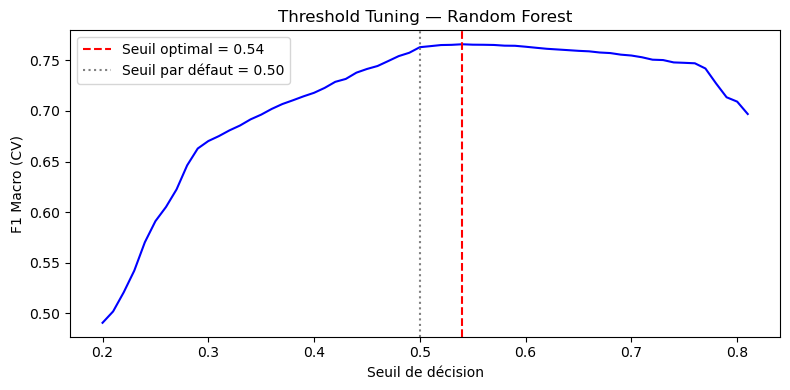

In [15]:
# --- Threshold Tuning : optimisation du seuil de décision ---
from sklearn.model_selection import cross_val_predict

y_proba_cv = cross_val_predict(
    best_rf, X_train_transformed, y_train,
    cv=cv_strat, method='predict_proba', n_jobs=-1
)

thresholds = np.arange(0.20, 0.81, 0.01)
f1_scores_thresh = np.array([
    f1_score(y_train, (y_proba_cv[:, 1] >= t).astype(int), average='macro')
    for t in thresholds
])

best_threshold = thresholds[np.argmax(f1_scores_thresh)]
best_f1_thresh = f1_scores_thresh.max()
f1_default = f1_score(y_train, (y_proba_cv[:, 1] >= 0.50).astype(int), average='macro')

print(f"Seuil par défaut (0.50) → F1 macro (CV) = {f1_default:.4f}")
print(f"Seuil optimal ({best_threshold:.2f})  → F1 macro (CV) = {best_f1_thresh:.4f}")

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores_thresh, 'b-')
ax.axvline(best_threshold, color='r', linestyle='--', label=f'Seuil optimal = {best_threshold:.2f}')
ax.axvline(0.50, color='gray', linestyle=':', label='Seuil par défaut = 0.50')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('F1 Macro (CV)')
ax.set_title('Threshold Tuning — Random Forest')
ax.legend()
plt.tight_layout()
plt.show()

RF Optimisé — Accuracy: 0.7896 | F1 Macro: 0.7686
  Seuil de décision : 0.54
  Features sélectionnées : 48/231

              precision    recall  f1-score   support

  Non-TP (0)       0.84      0.84      0.84     12284
      TP (1)       0.70      0.70      0.70      6644

    accuracy                           0.79     18928
   macro avg       0.77      0.77      0.77     18928
weighted avg       0.79      0.79      0.79     18928



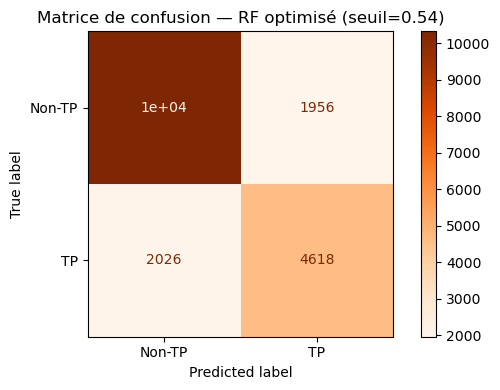

In [16]:
# --- Modèle RF optimisé : évaluation finale ---
rf_optimized = RandomForestClassifier(
    **random_search.best_params_,
    random_state=2026, n_jobs=-1
)
rf_optimized.fit(X_train_transformed[:, sel_idx], y_train)

y_proba_test = rf_optimized.predict_proba(X_test_transformed[:, sel_idx])
y_pred_rf_opt = (y_proba_test[:, 1] >= best_threshold).astype(int)

rf_opt_acc  = accuracy_score(y_test, y_pred_rf_opt)
rf_opt_f1   = f1_score(y_test, y_pred_rf_opt, average='macro')
rf_opt_prec = precision_score(y_test, y_pred_rf_opt, average='macro')
rf_opt_rec  = recall_score(y_test, y_pred_rf_opt, average='macro')

print(f"RF Optimisé — Accuracy: {rf_opt_acc:.4f} | F1 Macro: {rf_opt_f1:.4f}")
print(f"  Seuil de décision : {best_threshold:.2f}")
print(f"  Features sélectionnées : {len(sel_idx)}/{X_train_transformed.shape[1]}")
print(f"\n{classification_report(y_test, y_pred_rf_opt, target_names=TARGET_NAMES)}")

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_opt, display_labels=['Non-TP', 'TP'], ax=ax, cmap='Oranges')
ax.set_title(f'Matrice de confusion — RF optimisé (seuil={best_threshold:.2f})')
plt.tight_layout()
plt.show()

In [17]:
# --- Comparaison Baseline vs Optimisé ---
rf_comparison = pd.DataFrame({
    'Modèle': ['RF Baseline', 'RF Optimisé'],
    'Accuracy': [rf_base_acc, rf_opt_acc],
    'Precision Macro': [rf_base_prec, rf_opt_prec],
    'Recall Macro': [rf_base_rec, rf_opt_rec],
    'F1 Macro': [rf_base_f1, rf_opt_f1]
})
print(rf_comparison.to_string(index=False))

# Déterminer le meilleur
if rf_opt_f1 > rf_base_f1:
    best_rf_model_name = "RF Optimisé"
    rf_best = rf_optimized
    y_pred_rf_best = y_pred_rf_opt
else:
    best_rf_model_name = "RF Baseline"
    rf_best = rf_baseline
    y_pred_rf_best = y_pred_rf_base

print(f"\n>> Meilleur modèle RF : {best_rf_model_name}")
print(f">> Gain F1 vs Baseline : {(rf_opt_f1 - rf_base_f1)*100:+.2f}%")

     Modèle  Accuracy  Precision Macro  Recall Macro  F1 Macro
RF Baseline  0.775095         0.756962      0.773480  0.761843
RF Optimisé  0.789624         0.769234      0.767916  0.768562

>> Meilleur modèle RF : RF Optimisé
>> Gain F1 vs Baseline : +0.67%


## 5. Comparaison finale des trois modèles

Récapitulatif des performances de chaque modèle dans sa meilleure configuration :
- **Régression Logistique** : avec PCA + RandomizedSearchCV
- **KNN** : avec PCA + GridSearchCV (Elbow Method pour k initial)
- **Random Forest** : sans PCA + RandomizedSearchCV + sélection de features + threshold tuning

In [18]:
# --- Tableau comparatif final ---
final_comparison = pd.DataFrame({
    'Modèle': ['Régression Logistique (PCA)', 'KNN (PCA)', 'Random Forest'],
    'Accuracy': [reg_acc, knn_acc, rf_opt_acc if rf_opt_f1 > rf_base_f1 else rf_base_acc],
    'Precision Macro': [reg_prec, knn_prec, rf_opt_prec if rf_opt_f1 > rf_base_f1 else rf_base_prec],
    'Recall Macro': [reg_rec, knn_rec, rf_opt_rec if rf_opt_f1 > rf_base_f1 else rf_base_rec],
    'F1 Macro': [reg_f1, knn_f1, rf_opt_f1 if rf_opt_f1 > rf_base_f1 else rf_base_f1]
})
final_comparison = final_comparison.sort_values('F1 Macro', ascending=False)
print(final_comparison.to_string(index=False))

# Identifier le meilleur modèle global
best_global = final_comparison.iloc[0]
print(f"\n>> Meilleur modèle global : {best_global['Modèle']}")
print(f">> F1 Macro = {best_global['F1 Macro']:.4f}")

                     Modèle  Accuracy  Precision Macro  Recall Macro  F1 Macro
                  KNN (PCA)  0.801247         0.789542      0.762289  0.772051
              Random Forest  0.789624         0.769234      0.767916  0.768562
Régression Logistique (PCA)  0.791367         0.789584      0.737644  0.751605

>> Meilleur modèle global : KNN (PCA)
>> F1 Macro = 0.7721


### Analyse des erreurs par modèle

Le KNN semble être légèrement meilleur au vu des résultats des métriques mais les performances des trois modèles sont très sérrées. Donc pour mieux comprendre les forces et faiblesses de chaque modèle, nous analysons les matrices de confusion côte à côte. Cela permet de visualiser :
- Les **faux négatifs** (vrais incidents manqués) — critiques en cybersécurité
- Les **faux positifs** (fausses alertes) — coûteux en temps d'analyse
- Le **taux d'erreur par classe** pour chaque modèle

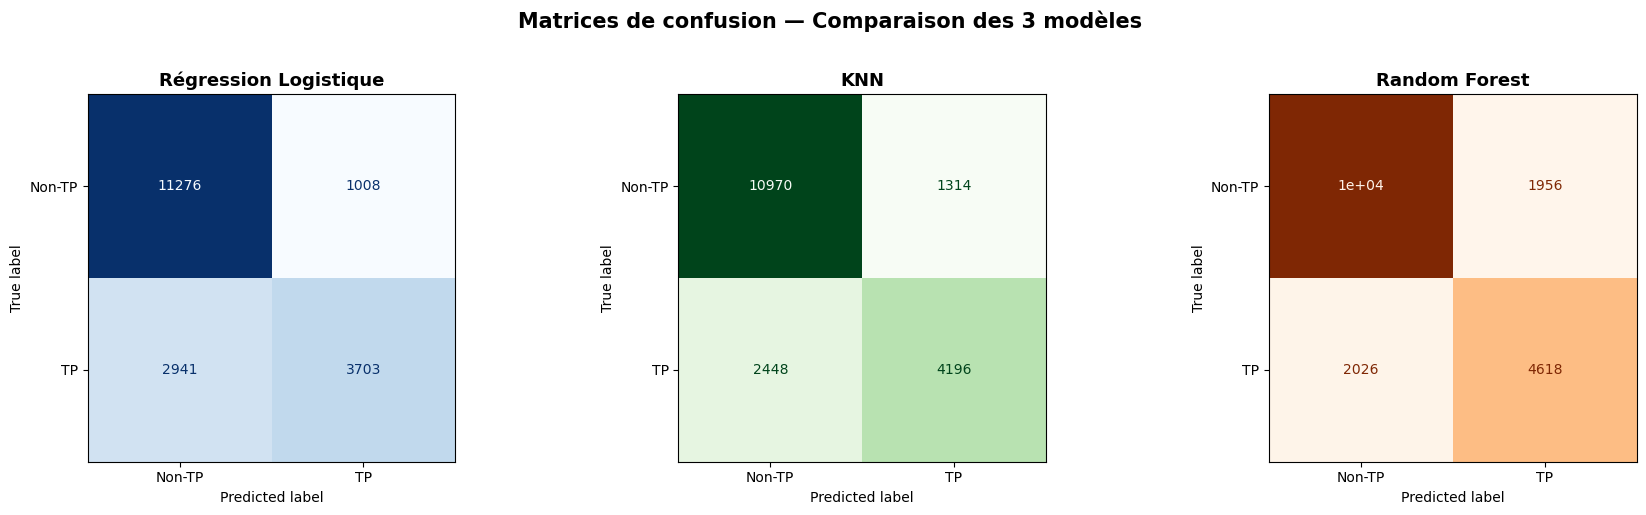

   ANALYSE DES ERREURS PAR MODÈLE

  Régression Logistique
  ──────────────────────────────────────────────────
    Vrais Négatifs  (Non-TP bien classés) : 11276 (59.6%)
    Faux Positifs   (fausses alertes)     :  1008 (5.3%)
    Faux Négatifs   (incidents manqués)   :  2941 (15.5%)
    Vrais Positifs  (incidents détectés)  :  3703 (19.6%)
    Taux d'erreur global : 20.86%

  KNN
  ──────────────────────────────────────────────────
    Vrais Négatifs  (Non-TP bien classés) : 10970 (58.0%)
    Faux Positifs   (fausses alertes)     :  1314 (6.9%)
    Faux Négatifs   (incidents manqués)   :  2448 (12.9%)
    Vrais Positifs  (incidents détectés)  :  4196 (22.2%)
    Taux d'erreur global : 19.88%

  Random Forest
  ──────────────────────────────────────────────────
    Vrais Négatifs  (Non-TP bien classés) : 10328 (54.6%)
    Faux Positifs   (fausses alertes)     :  1956 (10.3%)
    Faux Négatifs   (incidents manqués)   :  2026 (10.7%)
    Vrais Positifs  (incidents détectés)  :  4618 (24.

In [20]:
# --- Matrices de confusion côte à côte ---
models_preds = [
    ('Régression Logistique', y_pred_reg),
    ('KNN', y_pred_knn),
    ('Random Forest', y_pred_rf_best),
]
classes = ['Non-TP', 'TP']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ['Blues', 'Greens', 'Oranges']

for ax, (name, y_pred), cmap in zip(axes, models_preds, cmaps):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=classes, ax=ax, cmap=cmap, colorbar=False
    )
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Matrices de confusion — Comparaison des 3 modèles', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Analyse détaillée des erreurs ---
print("=" * 75)
print("   ANALYSE DES ERREURS PAR MODÈLE")
print("=" * 75)

for name, y_pred in models_preds:
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total = len(y_test)
    
    print(f"\n  {name}")
    print(f"  {'─' * 50}")
    print(f"    Vrais Négatifs  (Non-TP bien classés) : {tn:>5} ({tn/total*100:.1f}%)")
    print(f"    Faux Positifs   (fausses alertes)     : {fp:>5} ({fp/total*100:.1f}%)")
    print(f"    Faux Négatifs   (incidents manqués)   : {fn:>5} ({fn/total*100:.1f}%)")
    print(f"    Vrais Positifs  (incidents détectés)  : {tp:>5} ({tp/total*100:.1f}%)")
    print(f"    Taux d'erreur global : {(fp+fn)/total*100:.2f}%")

# --- Comparaison des erreurs critiques ---
print(f"\n{'=' * 75}")
print("   FOCUS : FAUX NÉGATIFS (incidents manqués — erreur la plus grave)")
print("=" * 75)
for name, y_pred in models_preds:
    cm = confusion_matrix(y_test, y_pred)
    fn = cm[1, 0]
    total_tp = cm[1].sum()
    print(f"  {name:<30} : {fn} incidents manqués sur {total_tp} ({fn/total_tp*100:.1f}%)")

On peut clairement voir que le Random Forest détecte mieux que les autres les vraies incidents qui est la cible principale. Dans le contexte actuel ou chaque ratement de la cible peut coûter très chère, alors on priorisa les prédictions du RF tout en prenant en compte celles des deux autres.

## 6. Export des modèles

Les modèles entraînés sont exportés dans le dossier `models/` au format `.joblib`, accompagnés de fichiers `.json` contenant les métadonnées (hyperparamètres, métriques, mapping des classes). Ces fichiers sont ensuite chargés par l'application Streamlit (`app.py`) pour la prédiction.

In [19]:
# --- Export des modèles vers models/ ---
import json

os.makedirs('models', exist_ok=True)

# Régression Logistique
joblib.dump(best_regression, 'models/best_regression.joblib')
reg_metadata = {
    "model_name": "Regression Logistique",
    "pca_components": int(pca.n_components_),
    "target_mapping": {k: int(v) for k, v in CIBLE_MAP.items()},
    "training_metrics": {
        "precision": float(reg_prec), "recall": float(reg_rec), "f1_macro": float(reg_f1)
    }
}
with open('models/reg_metadata.json', 'w') as f:
    json.dump(reg_metadata, f, indent=4)

# KNN + PCA
joblib.dump(best_knn, 'models/best_knn.joblib')
joblib.dump(pca, 'models/pca.joblib')
knn_metadata = {
    "model_name": "KNN Optimise",
    "k_neighbors": int(best_knn.n_neighbors),
    "pca_components": int(pca.n_components_),
    "target_mapping": {k: int(v) for k, v in CIBLE_MAP.items()},
    "training_metrics": {
        "precision": float(knn_prec), "recall": float(knn_rec), "f1_macro": float(knn_f1)
    }
}
with open('models/knn_metadata.json', 'w') as f:
    json.dump(knn_metadata, f, indent=4)

# Random Forest
joblib.dump(rf_best, 'models/rf_model.joblib')
rf_metadata = {
    "model_name": best_rf_model_name,
    "n_features_original": X_train_transformed.shape[1],
    "threshold": float(best_threshold),
    "target_mapping": CIBLE_MAP,
    "target_names": TARGET_NAMES,
    "training_metrics": {
        "precision": float(rf_opt_prec if rf_opt_f1 > rf_base_f1 else rf_base_prec),
        "recall": float(rf_opt_rec if rf_opt_f1 > rf_base_f1 else rf_base_rec),
        "f1_macro": float(rf_opt_f1 if rf_opt_f1 > rf_base_f1 else rf_base_f1)
    }
}
if best_rf_model_name == "RF Optimisé":
    rf_metadata["selected_features_indices"] = sel_idx.tolist()
    rf_metadata["n_features_selected"] = len(sel_idx)

with open('models/rf_metadata.json', 'w') as f:
    json.dump(rf_metadata, f, indent=4)

print("Export terminé dans models/ :")
for f_name in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f_name}') / 1024
    print(f"  {f_name:<30} ({size:.1f} KB)")

Export terminé dans models/ :
  best_knn.joblib                (26026.1 KB)
  best_regression.joblib         (1.2 KB)
  knn_metadata.json              (0.3 KB)
  pca.joblib                     (81.4 KB)
  reg_metadata.json              (0.3 KB)
  rf_metadata.json               (1.0 KB)
  rf_model.joblib                (34059.9 KB)
